In [2]:
%run utilities_general.ipynb 
%run utilities_DIRKs_and_PIRKs.ipynb
load_standard_packages()
change_wordir()
from matplotlib.lines import Line2D

C:\Users\andre\AppData\Local\Temp\ipykernel_29824\1467589274.py:1: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  from scipy import interpolate
Could not find cannot import name 'dopri5' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'rodas' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'odassl' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find ODEPACK functions.
Could not find RADAR5
Could not find GLIMDA.


1.58.0


In [3]:
analysis = "kinetic_analysis"

colors, colours = colourblind_palette("own")

model = "with_dpsi"
#model = "latest_dev"

m = load_model(model)


succesfully loaded with_dpsi :D


In [4]:
# I like to have light as a derived variable
m.add_algebraic_module(module_name = "Light",
    function = lambda X, PFD: PFD, # X is not used
    compounds = ["PQ"], derived_compounds = ["L"], parameters = ['pfd'])

In [5]:
y0 = get_stst_y0(m, pfd =70) # pfd = 1200

In [6]:
# file_name = "PIRK_ECS_20250721_leaf4_500_to_2500_4000peak_new_wind_length.json"
file_name_1 = "PIRK_ECS_20250805_Ocimum_basilicum.json"
file_name_2 = "PIRK_ECS_20250805_Petroselinum_crispum.json"

with open(f"data/{file_name_1}", 'r') as file:
    json_data_1 = json.load(file)


with open(f"data/{file_name_2}", 'r') as file:
    json_data_2 = json.load(file)

In [7]:
results1 = analyze_PIRK_from_MultispeQ(json_data_1,
                                    Protocol_label = "PIRK_ECS",
                                    #Protocol_label = "PIRK_P700_hl",
                                    show_abs_traces = False,
                                    #datapoints_to_use = 30,
                                    show_fits="",
                                    use_fixed_fit_wndw_len = True
                                    )

results2 = analyze_PIRK_from_MultispeQ(json_data_2,
                                    Protocol_label = "PIRK_ECS",
                                    #Protocol_label = "PIRK_P700_hl",
                                    show_abs_traces = False,
                                    #datapoints_to_use = 30,
                                    show_fits="",
                                    use_fixed_fit_wndw_len = True
                                    )
results1

protocol indeces: [15, 17, 32, 34, 54, 56, 96, 98, 178, 180, 340, 342, 662, 664, 984]
shortest window length detected: 15
dt = 1.012, 7 relaxation windows fitted for 35 PAR levels.
protocol indeces: [15, 17, 32, 34, 54, 56, 96, 98, 178, 180, 340, 342, 662, 664, 984]
shortest window length detected: 15
dt = 1.012, 7 relaxation windows fitted for 35 PAR levels.


,PAR,time,amplitude,peak_hight,baseline,Tau,rate,flux,r_squared,traces,simulation_meta_info
0,30,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[0.8130611024294063, 1.524743880075738, 1.3223...","[1.265320055259978, 1.3034630296349137, 1.6782...","[0.4531792110257881, 0.2560581898336986, 0.971...","[5.228416764090119, 18.12668504189378, 9.67931...","[0.1912624882676173, 0.05516728501040504, 0.10...","[0.15550808956426032, 0.08411598020000909, 0.1...","[0.8239058050842052, 0.8737317222145602, 0.950...","{'absorbance': [nan, nan, -0.10074478535419919...","[(15.18, 30), (17.204, 2500), (32.384, 0), (34..."
1,40,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[0.9731357895594732, 1.2717720343780394, 1.132...","[1.0630321916313288, 1.363806331670358, 1.3452...","[0.1267631297087342, 0.27194957403584386, 0.23...","[5.222950068436074, 4.14467235591463, 7.058616...","[0.19146267662854252, 0.241273595142679, 0.141...","[0.18631918299208683, 0.3068450109363083, 0.16...","[0.9050527931749394, 0.9200654394164199, 0.944...","{'absorbance': [nan, nan, -0.06729478911595146...","[(15.18, 40), (17.204, 2500), (32.384, 0), (34..."
2,50,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[0.978706346200588, 1.2787266992872235, 0.9966...","[1.1172908172076175, 1.2632036693975446, 1.344...","[0.0534093543984288, 0.12559803823202365, 0.27...","[4.62417270935416, 4.224581565794446, 3.116746...","[0.21625489851992705, 0.236709833725733, 0.320...","[0.21165004157841677, 0.30268718436893405, 0.3...","[0.900309765206557, 0.9445277166081204, 0.9466...","{'absorbance': [nan, nan, 0.1293106886689264, ...","[(15.18, 50), (17.204, 2500), (32.384, 0), (34..."
3,60,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[1.1052607599926207, 1.2128691975894648, 1.261...","[1.0533282953507652, 1.2622246030823765, 1.398...","[-0.11484464580589629, -0.04412864172878811, -...","[4.741564562790116, 4.0740507934467125, 4.6557...","[0.21090085071235687, 0.24545594807225854, 0.2...","[0.2331004345414298, 0.29770595878196154, 0.27...","[0.8552379718530976, 0.8923246074481277, 0.950...","{'absorbance': [nan, nan, -0.05591836072647826...","[(15.18, 60), (17.204, 2500), (32.384, 0), (34..."
4,70,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[0.9531548348279253, 1.284552356175819, 1.1446...","[0.9522453520187031, 1.1793799101342752, 1.333...","[-0.07594712175576625, -0.13592301047069166, -...","[3.9316529031561407, 4.478593882897396, 3.1921...","[0.25434595185074665, 0.22328436695694692, 0.3...","[0.24243107372544986, 0.28682045967177233, 0.3...","[0.9526038950063659, 0.9351148701308095, 0.922...","{'absorbance': [nan, nan, -0.08002798004312245...","[(15.18, 70), (17.204, 2500), (32.384, 0), (34..."
5,85,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[1.3148026586321149, 1.228290690238184, 1.3347...","[1.2193826498480773, 1.1374719776842839, 1.549...","[-0.13871398562003767, -0.1722591702357441, -0...","[3.9965184525072046, 4.80781159088608, 3.75212...","[0.25021778627661606, 0.20799483945994232, 0.2...","[0.3289870106335371, 0.25547812492623284, 0.35...","[0.9227028521553555, 0.9587165879004172, 0.978...","{'absorbance': [nan, nan, -0.06261644822936926...","[(15.18, 85), (17.204, 2500), (32.384, 0), (34..."
6,100,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[1.2393753232060927, 1.1923223577084154, 1.282...","[1.132922971846307, 1.1595411877194097, 1.4679...","[-0.10588777584858568, -0.26719829643495546, -...","[3.052486341492949, 4.843381750387314, 2.96229...","[0.32760179346483403, 0.2064673097304445, 0.33...","[0.4060215786583743, 0.24617558952751725, 0.43...","[0.9056027741482219, 0.9598020015169167, 0.957...","{'absorbance': [nan, nan, 0.1342806294234281, ...","[(15.18, 100), (17.204, 2500), (32.384, 0), (3..."
7,150,"[17.204, 34.408, 56.672, 99.176, 182.16, 346.1...","[1.455937845852913, 1.3047591458359524, 1.4420...","[0.9265300422262331, 1.2305216968721049, 1.448...","[-0.4782175600432161, -0.32475729061299274, -0...","[7.60498746568547

In [14]:
s = Simulator(m)

# s.update_parameter("pHstroma", 7.9)
# s.update_parameter("pKreg", 6.2)
#s.update_parameter("max_b6f", 400) # 500
# s.update_parameter("kPCox", 2500) # 2500
# s.update_parameter("kATPsynth", 2.0) # 20
#s.update_parameter("k", 8e7) # 8e8
#s.update_parameter("k2", 9e9) # 59
# s.update_parameter("kLeak",0)#10

s.initialise(y0)

idx_to_plot = 33

protocol = results1.loc[idx_to_plot,"simulation_meta_info"]
print(protocol)

AL_level = protocol[0][1]

c, v = apply_protocol(s, protocol, protocol_time_is_accumulated = True, use_tqdm = False, shift_time = False, input_in_ms = True, output_in_ms= True)

[(np.float64(15.18), 1900), (np.float64(17.204), 2500), (np.float64(32.384), 0), (np.float64(34.408), 2500), (np.float64(54.648), 0), (np.float64(56.672), 2500), (np.float64(97.152), 0), (np.float64(99.176), 2500), (np.float64(180.136), 0), (np.float64(182.16), 2500), (np.float64(344.08), 0), (np.float64(346.104), 2500), (np.float64(669.944), 0), (np.float64(671.968), 2500), (np.float64(995.808), 0)]


In [15]:
measurement1 = results1["traces"][idx_to_plot]["absorbance"]
measurement2 = results2["traces"][idx_to_plot]["absorbance"]
#simulation = c["rel_P700+"]
simulation = c["dpsi"]
#simulation = 7.9 - c["pH"]

In [16]:
#simulation

In [17]:
norm_meas1, norm_meas2, norm_sim = minmax_with_baseline([measurement1, measurement2, simulation], baseline_indexes_seeling_and_length = (protocol[0][0]-2, 15), smoothing_window_length = 10)

#save traces as pd.Series with time as information! add this as a feature in the above functions!

detected baseline window ranging from index 0 to 15
detected baseline window ranging from index 0 to 15


detected baseline window ranging from index 0 to 6


[(-0.05, 1.2), (0.0, 1000.0), Text(0.5, 0, 'Time (ms)')]

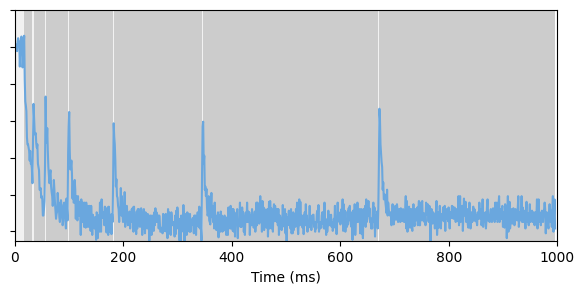

In [18]:
fig, ax = plt.subplots(figsize=(7, 3)) #6, 3; 15, 4

# ax.plot(norm_sim.index, norm_sim, label="Simulation", color=colors[2], linewidth = 2, linestyle = "-") 
ax.plot(norm_meas1.index, norm_meas1, label="O. basilicum", color=colors[0], linestyle = "-")
# ax.plot(norm_meas2.index, norm_meas2, label="P. crispum", color=colors[1], linestyle = "-")


shade_light(c, ax)
ax.set_yticklabels([])

# light_level_label = Line2D([], [], color='none', label=f"{AL_level} µE")
# ax.add_artist(ax.legend(handles=[light_level_label], loc="upper right", handlelength=0, handletextpad=0))

ax.set(ylim=(-0.05,1.2),
       xlim=(0, 1000),
       xlabel=("Time (ms)")
       )

#ax.set_xlim(100,300)
# ax.legend(loc="upper center", bbox_to_anchor = (0.65,1))
#ax.set_yscale("log")

In [309]:
#save_fig(fig, "PIRKs" ,"sim_meas_fit_overlay",  f"PIRK_simulation_two_herbs_ECS_{AL_level}pfd")
save_fig(fig, "PIRKs" ,"sim_meas_fit_overlay",  f"PIRK_simulation_two_herbs_ECS_{AL_level}pfd_zoom")

existing figure backed up to figures/PIRKs/sim_meas_fit_overlay/Z_backup_PIRK_simulation_two_herbs_ECS_2000pfd_zoom.png
saved figure to figures/PIRKs/sim_meas_fit_overlay/PIRK_simulation_two_herbs_ECS_2000pfd_zoom.png
